# Identification reports, residual-aware gating, and finite-sample invariance

This notebook fills an opt-in
`IdentificationReport` on a linear Gaussian per-node
trajectory, rejects a polluted RMSE-only dictionary with
`select_resdmd_gated`, and reads finite-sample leakage $\eta$
on a rank-deficient line. One-step and short-rollout mean
squared error (MSE) are both near zero when $K$ is recovered
from consecutive states.

**Honesty.** Default `fit(..., identification=None)` remains Adam and
does not import `koopman_graph.identification`. The report records
finite-sample latent MSE and $\rho(K)$, not a Haseli–Cortés
certificate and not a certified ResDMD bound. Discrete dense per-node
$K$ only. Residual cutoff default is $10^{-2}$. $\eta$ is a
truncated-SVD projection residual; when numerical rank equals the
ambient latent width it is identically zero. This notebook does
**not** download METR-LA.


## Setup

Package version, identity encoder/decoder, a shared $2\times 2$
map, and the identification helpers (off the root façade).


In [1]:
from __future__ import annotations

import os
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch
from IPython.display import display
from torch import Tensor, nn
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import koopman_graph
from koopman_graph.analysis.resdmd import resdmd
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.identification import (
    DEFAULT_RESDMD_GATE_TOLERANCE,
    IdentificationConfig,
    IdentificationReport,
    LatentPairs,
    ResDMDGateCandidate,
    build_identification_report,
    identify_operator,
    select_resdmd_gated,
    subspace_invariance_report,
)
from koopman_graph.model import GraphKoopmanModel

SEED = 0
TRUE_K = torch.tensor([[0.9, 0.15], [-0.05, 0.55]], dtype=torch.float64)
LINE_DIR = torch.tensor([1.0, 2.0], dtype=torch.float64)
SCALE_K = 0.5 * torch.eye(2, dtype=torch.float64)
LEAVE_K = torch.tensor([[0.0, -1.0], [1.0, 0.0]], dtype=torch.float64)


class IdentityCodec(nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.in_channels = dim
        self.latent_dim = dim
        self.out_channels = dim
        self.num_layers = 1

    def forward(self, x_or_data, edge_index=None, edge_weight=None):
        del edge_index, edge_weight
        if isinstance(x_or_data, Data):
            return x_or_data.x
        return x_or_data


def linear_sequence(true_k: Tensor, *, n_nodes: int = 4, n_times: int = 16):
    dim = true_k.shape[0]
    generator = torch.Generator().manual_seed(SEED)
    state = torch.randn(n_nodes, dim, dtype=true_k.dtype, generator=generator)
    src = list(range(n_nodes - 1))
    dst = list(range(1, n_nodes))
    edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long)
    snapshots = []
    for _ in range(n_times):
        snapshots.append(Data(x=state.clone(), edge_index=edge_index))
        state = state @ true_k.T
    return GraphSnapshotSequence(snapshots)


def trajectory_pairs(true_k: Tensor, *, n_times: int = 24, seed: int = SEED):
    generator = torch.Generator().manual_seed(seed)
    state = torch.randn(true_k.shape[0], dtype=true_k.dtype, generator=generator)
    rows = [state.clone()]
    for _ in range(n_times - 1):
        state = state @ true_k.T
        rows.append(state.clone())
    traj = torch.stack(rows, dim=0)
    return traj, LatentPairs(z_t=traj[:-1], z_next=traj[1:])


def rank1_line(*, n_times: int = 16) -> Tensor:
    amplitude = torch.linspace(0.2, 1.6, n_times, dtype=torch.float64)
    return amplitude.unsqueeze(1) * LINE_DIR


def one_step_mse(psi0: Tensor, psi1: Tensor) -> float:
    solution = torch.linalg.lstsq(psi0, psi1).solution
    return float((psi0 @ solution - psi1).square().mean().item())


def residual_max(psi0: Tensor, psi1: Tensor) -> float:
    return float(
        resdmd(psi0, psi1, tolerance=DEFAULT_RESDMD_GATE_TOLERANCE)
        .residuals.max()
        .real.item()
    )


print("koopman_graph", koopman_graph.__version__)
print("DEFAULT_RESDMD_GATE_TOLERANCE", DEFAULT_RESDMD_GATE_TOLERANCE)


koopman_graph 0.15.0
DEFAULT_RESDMD_GATE_TOLERANCE 0.01


## Motivation and background

Default `fit` writes $K$ with Adam. Closed-form ridge (Williams,
Kevrekidis, and Rowley, 2015) can instead write a dense per-node
$K$ on frozen encodings when the caller passes
`IdentificationConfig`. Two failure modes remain.

First, RMSE-only dictionary selection can prefer a lift that
concatenates a leaked future coordinate: train one-step MSE
falls while the dictionary is no longer approximately invariant.
Finite-dictionary residual dynamic mode decomposition
(ResDMD) residuals (Colbrook and Townsend, *Comm. Pure Appl.
Math.*, 2023/2024) are a gate on that pollution, not an
infinite-dimensional spectral measure.

Second, `fit` does not fill `IdentificationReport.invariance`.
Finite-sample leakage $\eta$ is the mean residual of $K\psi$
off the truncated-SVD span of the encodings, divided by the
mean $\|K\psi\|_2$. It is not the Haseli–Cortés
invariance-proximity certificate (principal angles / worst-case
bound; arXiv:2311.13033). When that span is the whole ambient
$\mathbb{R}^{d}$, $P=I$ and $\eta=0$ by construction.


## Minimal example

Identify $K$ on consecutive states of one linear trajectory
(`LatentPairs` with time along axis 0). One-step and
short-rollout MSE should both be near zero; $\rho(K)$ should
match the oracle. This is not an i.i.d. cloud:
`build_identification_report` treats a 2-D pair's sample axis
as time.


In [2]:
_traj, pairs = trajectory_pairs(TRUE_K, n_times=24)
snapshot = identify_operator(
    pairs, IdentificationConfig(solver="ridge", ridge=0.0)
)
report = build_identification_report(pairs, snapshot, gate_resdmd=True)
assert isinstance(report, IdentificationReport)
assert report.one_step.mse is not None
assert report.rollout.mse is not None
assert report.stability.spectral_radius is not None
assert report.spectral.residual_max is not None
assert report.spectral.polluted is False
print("one_step.mse", report.one_step.mse)
print("rollout.mse", report.rollout.mse)
print("rho(K)", report.stability.spectral_radius)
print("residual_max", report.spectral.residual_max)
assert report.one_step.mse < 1e-20
assert report.rollout.mse < 1e-20


one_step.mse 4.924859309557061e-33
rollout.mse 8.283424690809502e-32
rho(K) 0.8770690632574556
residual_max 3.398598988250878e-08


## Progressive deep dive

Leakage $\eta$ is informative only when the encoding rank is
smaller than the ambient width. On a rank-1 line in
$\mathbb{R}^{2}$, a scaling map stays in span and a rotation
leaves it. `held_out=False` uses the whole line so the
contrast is not a hold-out artifact.

A polluted lift that concatenates a leaked future first
coordinate then wins train one-step MSE.
`select_resdmd_gated` drops that candidate when the max
residual exceeds $10^{-2}$. The leaked coordinate uses a true
$t+2$ target (pairs that lack a successor are dropped; no
wrap-around pad).


In [3]:
line = rank1_line(n_times=16)
eta_scale = subspace_invariance_report(line, SCALE_K, held_out=False)
eta_leave = subspace_invariance_report(line, LEAVE_K, held_out=False)
print("scale leakage", eta_scale.leakage, "rank", eta_scale.rank)
print("rotation leakage", eta_leave.leakage, "rank", eta_leave.rank)
assert eta_scale.rank == 1
assert eta_leave.rank == 1
assert eta_scale.leakage < 1e-12
assert abs(eta_leave.leakage - 1.0) < 1e-8


scale leakage 1.878117727256971e-16 rank 1
rotation leakage 1.0 rank 1


The rank-1 line is the case where $\eta$ can fail. The next
cell scores a leaked-future dictionary against the identity
lift.

In [4]:
def noisy_traj(true_k: Tensor, *, n_times: int, noise: float, seed: int) -> Tensor:
    generator = torch.Generator().manual_seed(seed)
    state = torch.tensor([0.4, -0.2], dtype=true_k.dtype)
    rows = []
    for _ in range(n_times):
        rows.append(state.clone())
        state = state @ true_k.T + noise * torch.randn(
            2, dtype=true_k.dtype, generator=generator
        )
    return torch.stack(rows, dim=0)


traj = noisy_traj(TRUE_K, n_times=48, noise=1e-4, seed=0)
psi0, psi1 = traj[:-2], traj[1:-1]
junk0 = traj[1:-1, :1]
junk1 = traj[2:, :1]
pol0 = torch.cat([psi0, junk0], dim=1)
pol1 = torch.cat([psi1, junk1], dim=1)
clean = ResDMDGateCandidate(
    name="identity",
    mse=one_step_mse(psi0, psi1),
    residual_max=residual_max(psi0, psi1),
)
polluted = ResDMDGateCandidate(
    name="identity_plus_junk",
    mse=one_step_mse(pol0, pol1),
    residual_max=residual_max(pol0, pol1),
)
print("identity mse", clean.mse, "residual_max", clean.residual_max)
print("polluted mse", polluted.mse, "residual_max", polluted.residual_max)
assert polluted.mse < clean.mse
assert clean.residual_max <= DEFAULT_RESDMD_GATE_TOLERANCE
assert polluted.residual_max > DEFAULT_RESDMD_GATE_TOLERANCE
rmse_only = select_resdmd_gated((clean, polluted), gate_resdmd=False)
gated = select_resdmd_gated((clean, polluted), gate_resdmd=True)
print("RMSE-only selected", rmse_only.selected)
print("gated selected", gated.selected, "rejected", gated.rejected_alternatives)
assert rmse_only.selected == "identity_plus_junk"
assert gated.selected == "identity"
assert gated.rejected_alternatives == ("identity_plus_junk",)


identity mse 9.726491598197258e-09 residual_max 0.00414914219142909
polluted mse 6.065363689866264e-09 residual_max 0.8553478893997141
RMSE-only selected identity_plus_junk
gated selected identity rejected ('identity_plus_junk',)


## Results

Opt-in `fit(..., identification=IdentificationConfig(...))`
writes the same report on the identity-codec graph oracle.
Default Adam leaves `identification_report` unset.
`evaluate(..., include_invariance=True)` attaches $\eta$ on
the encoded cloud; here rank equals `latent_dim`, so the
leakage is machine zero (the tautology from Motivation).

Figure 1 (left) shows one-step MSE: the polluted dictionary is
the RMSE-only winner. Figure 1 (right) shows the max ResDMD
residual with both values labeled: only the leaked lift
exceeds the $10^{-2}$ cutoff (dashed). Figure 2 shows $\eta$
on the rank-1 line (scale vs rotation) and on the full-rank
`evaluate` cloud.


In [5]:
sequence = linear_sequence(TRUE_K)
model = GraphKoopmanModel(
    encoder=IdentityCodec(2),
    decoder=IdentityCodec(2),
    latent_dim=2,
    time_step=1.0,
    koopman_init_mode="identity",
    koopman_init_scale=0.0,
).to(dtype=torch.float64)
history = model.fit(
    sequence,
    epochs=2,
    identification=IdentificationConfig(solver="ridge", ridge=0.0, gate_resdmd=True),
)
fit_report = model.identification_report
assert isinstance(fit_report, IdentificationReport)
assert fit_report.one_step.mse is not None
assert fit_report.spectral.residual_max is not None
assert fit_report.spectral.polluted is False
print("fit epochs", history.epochs)
print("fit one_step.mse", fit_report.one_step.mse)
print("fit residual_max", fit_report.spectral.residual_max)

eval_result = model.evaluate(
    sequence, horizons=(3, 6, 12), include_invariance=True
)
assert eval_result.invariance is not None
print(
    "evaluate eta",
    eval_result.invariance.leakage,
    "rank",
    eval_result.invariance.rank,
    "held_out",
    eval_result.invariance.held_out,
)
assert eval_result.invariance.rank == 2
assert eval_result.invariance.leakage < 1e-12

adam = GraphKoopmanModel(
    encoder=IdentityCodec(2),
    decoder=IdentityCodec(2),
    latent_dim=2,
    time_step=1.0,
    koopman_init_mode="identity",
    koopman_init_scale=0.0,
).to(dtype=torch.float64)
adam.fit(sequence, epochs=1, lr=1e-2)
assert adam.identification_report is None
print("default Adam identification_report", adam.identification_report)


fit epochs 2
fit one_step.mse 1.057457916267142e-31
fit residual_max 0.0
evaluate eta 1.1114968235444816e-16 rank 2 held_out True
default Adam identification_report None


Figure 1 uses the gate scores from the deep dive. Figure 2
uses the rank-1 leakages and the `evaluate` cloud.

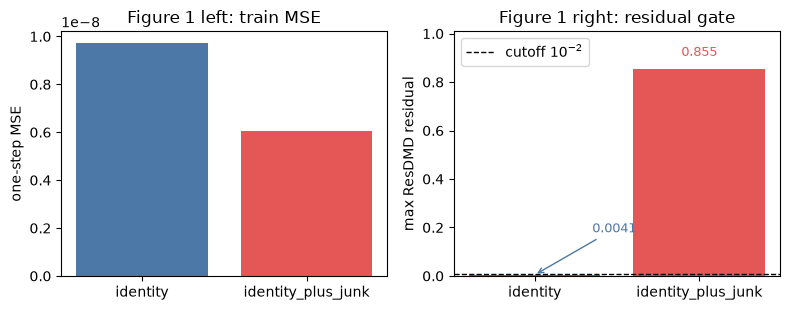

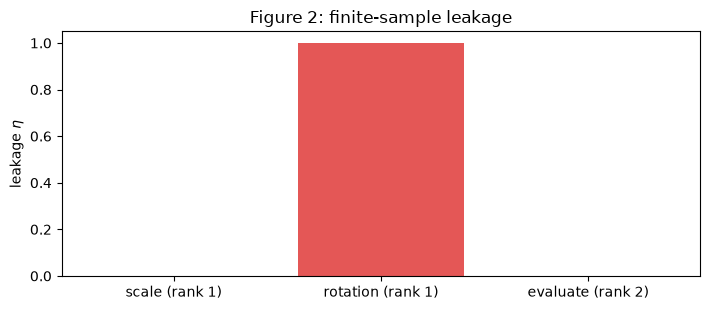

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.2))
names = (clean.name, polluted.name)
axes[0].bar(names, (clean.mse, polluted.mse), color=("#4c78a8", "#e45756"))
axes[0].set_ylabel("one-step MSE")
axes[0].set_title("Figure 1 left: train MSE")
axes[1].bar(
    names,
    (clean.residual_max, polluted.residual_max),
    color=("#4c78a8", "#e45756"),
)
axes[1].axhline(
    DEFAULT_RESDMD_GATE_TOLERANCE,
    color="black",
    linestyle="--",
    linewidth=1,
    label=r"cutoff $10^{-2}$",
)
axes[1].set_ylabel("max ResDMD residual")
axes[1].set_title("Figure 1 right: residual gate")
axes[1].annotate(
    f"{clean.residual_max:.4f}",
    xy=(0, clean.residual_max),
    xytext=(0.35, 0.18),
    textcoords="data",
    ha="left",
    color="#4c78a8",
    fontsize=9,
    arrowprops={"arrowstyle": "->", "color": "#4c78a8", "lw": 1},
)
axes[1].annotate(
    f"{polluted.residual_max:.3f}",
    xy=(1, polluted.residual_max),
    xytext=(1, polluted.residual_max + 0.04),
    ha="center",
    va="bottom",
    color="#e45756",
    fontsize=9,
)
axes[1].set_ylim(0.0, polluted.residual_max * 1.18)
axes[1].legend(loc="upper left")
fig.tight_layout()
display(fig)
plt.close(fig)

fig2, ax = plt.subplots(figsize=(7.2, 3.2))
labels = ("scale (rank 1)", "rotation (rank 1)", "evaluate (rank 2)")
values = (
    eta_scale.leakage,
    eta_leave.leakage,
    float(eval_result.invariance.leakage),
)
ax.bar(labels, values, color=("#4c78a8", "#e45756", "#72b7b2"))
ax.set_ylabel(r"leakage $\eta$")
ax.set_title("Figure 2: finite-sample leakage")
fig2.tight_layout()
display(fig2)
plt.close(fig2)


## Interpretation / discussion

Report fields used here are `one_step`, `rollout`,
`stability.spectral_radius`, and gated `spectral`. On a true
trajectory those MSE slots agree (both $\ll 10^{-20}$). On
i.i.d. 2-D pairs, rollout MSE can be $O(1)$ even when $K$ is
exact — that is a layout artifact, not a failed solve. The
graph-oracle `fit` residual can print as `0.0` because the
trajectory is noise-free; the helper residual on the 24-step
line is $\sim 10^{-8}$.

`fit` does **not** populate `invariance`. Read $\eta$ from
`subspace_invariance_report` or `evaluate(..., include_invariance=True)`.
The evaluate path on this full-rank identity codec is the
tautology ($P=I$, rank $= d$). The rank-1 line is the case that
can fail.

The polluted dictionary is the RMSE-only winner (lower
one-step MSE) and the gated reject (max residual
$\approx 0.86 > 10^{-2}$). The identity residual
($\approx 4 \times 10^{-3}$) sits below the cutoff. This is
not a Haseli–Cortés certificate. Networked, continuous, and
controlled operators are out of scope.


## Takeaways

- Reach for opt-in identification when you want a closed-form
  dense per-node $K$ and a finite-sample report. Default
  `fit(..., identification=None)` stays Adam.
- Use `select_resdmd_gated` when an RMSE-only lift may be
  polluted by a leaked future coordinate. The $10^{-2}$ cutoff
  is a finite-dictionary gate, not a certified bound.
- Read $\eta$ on a proper subspace (rank $< d$). When
  rank $= d$, $\eta$ is identically zero and is not evidence
  of invariance.
- Do not treat i.i.d. 2-D `LatentPairs` as a trajectory:
  rollout MSE then compares $K^{t} z_{0}$ to unrelated rows.
- Do not use this path for networked `koopman="graph"` /
  hetero / continuous / controlled operators, or for
  `solver="varpro"` (not implemented).


## Further reading

- Sphinx: [identification](../docs/source/identification.rst),
  [faq](../docs/source/faq.rst), [limitations](../docs/source/limitations.rst)
- Williams, Kevrekidis, and Rowley (2015), *J. Nonlinear Sci.*
  ([doi:10.1007/s00332-015-9258-5](https://doi.org/10.1007/s00332-015-9258-5))
- Colbrook and Townsend (2023/2024), *Comm. Pure Appl. Math.*
  ([doi:10.1002/cpa.22125](https://doi.org/10.1002/cpa.22125))
- Haseli and Cortés (2023), arXiv:2311.13033
  ([doi:10.48550/arXiv.2311.13033](https://doi.org/10.48550/arXiv.2311.13033))
- Example [53_latent_rank_selection.ipynb](53_latent_rank_selection.ipynb)
